In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Load the dataset
df = pd.read_csv(r'C:\Users\sumit\DATA_SCIENCE\THE DEVELOPER ARENA INTERNSHIP\Week 11\customer_churn.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


### Data Inspection

In [19]:
# Get a concise summary of the DataFrame
print('\nDataFrame Info:')
df.info()

# Display descriptive statistics
print('\nDescriptive Statistics:')
display(df.describe())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB

Descriptive Statistics:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


### Preprocessing for Clustering

Based on the data inspection, we need to preprocess the data for clustering. This involves:
1.  **Handling categorical features**: `Gender`, `Geography`, `HasCrCard`, `IsActiveMember`, and `Exited` will be one-hot encoded.
2.  **Scaling numerical features**: `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `EstimatedSalary` will be scaled using `StandardScaler`.
3.  **Dropping irrelevant columns**: `RowNumber`, `CustomerId`, and `Surname` are identifiers and not useful for clustering. The `Exited` column is the target variable for churn prediction, not for clustering customer segments, so it will also be dropped for unsupervised clustering.

In [20]:
# Drop irrelevant columns for clustering
df_processed = df.drop(columns=['CustomerID', 'Churn'])

# Identify categorical and numerical features based on the *actual* dataset columns
categorical_features = df_processed.select_dtypes(include=['object', 'bool']).columns
numerical_features = df_processed.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply preprocessing
X_preprocessed = preprocessor.fit_transform(df_processed)

# Get feature names after one-hot encoding
# This step is a bit complex due to OneHotEncoder dynamically naming columns
# Ensure we get the correct numerical feature names first
processed_numerical_features = list(numerical_features)
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = processed_numerical_features + list(encoded_feature_names)

# Convert the preprocessed data back to a DataFrame for easier inspection (optional, but good for understanding)
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_feature_names)

print('\nShape of preprocessed data:', X_preprocessed.shape)
print('\nFirst 5 rows of preprocessed data (as DataFrame for clarity):')
display(X_preprocessed_df.head())


Shape of preprocessed data: (500, 12)

First 5 rows of preprocessed data (as DataFrame for clarity):


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank Transfer,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaperlessBilling_No,PaperlessBilling_Yes
0,-1.478807,-0.959185,-1.194621,1.004008,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.752287,-0.012290,-1.100305,1.004008,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-0.461679,-1.596890,-1.232259,1.004008,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,0.797622,-1.635539,1.289485,1.004008,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,-0.994460,1.379066,-1.423548,1.004008,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


### K-Means Clustering

Let's apply K-Means clustering to the preprocessed data. First, we need to determine an appropriate number of clusters (k). We'll use two common methods for this: the Elbow Method and the Silhouette Score.

#### Elbow Method to find optimal K

C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

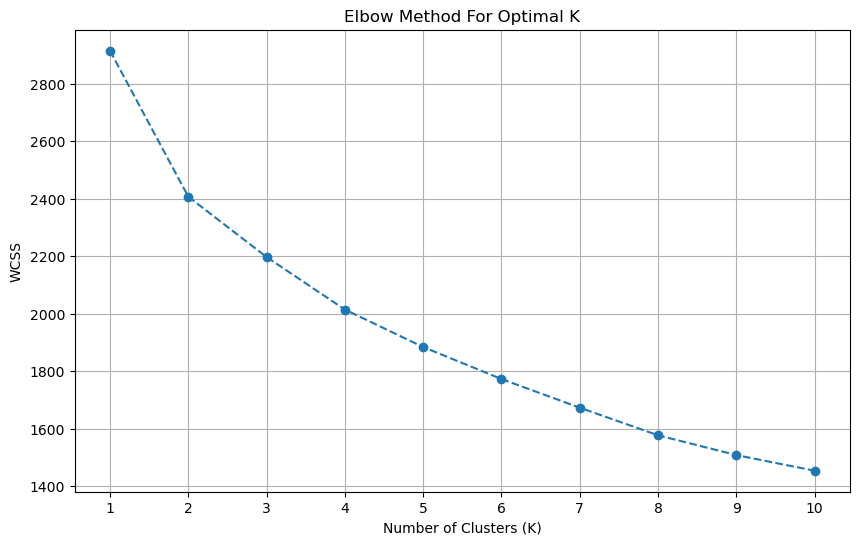

In [21]:
# Calculate WCSS (Within-Cluster Sum of Squares) for different number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_preprocessed)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

#### Silhouette Score to find optimal K

C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

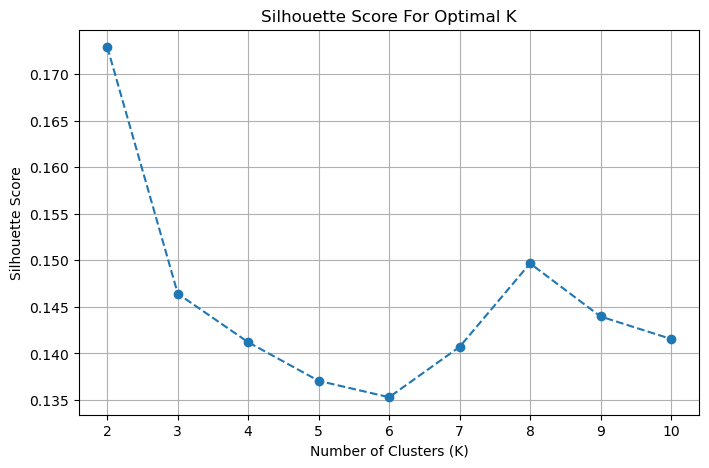

In [34]:
# Calculate Silhouette Scores for different number of clusters
silhouette_scores = []
# Silhouette score requires at least 2 clusters
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_preprocessed)
    score = silhouette_score(X_preprocessed, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the Silhouette Score graph
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

Based on the Elbow Method and Silhouette Score, let's choose an optimal `k` (e.g., 3 or 4 seems reasonable from a quick glance). For demonstration purposes, let's proceed with `k=3`.

In [23]:
# Apply K-Means with the chosen number of clusters (e.g., k=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_preprocessed)

# Add cluster labels to the preprocessed DataFrame for analysis
X_preprocessed_df['KMeans_Cluster'] = kmeans_labels

print(f'K-Means clustering performed with {optimal_k} clusters.')
print('\nCluster distribution:')
print(X_preprocessed_df['KMeans_Cluster'].value_counts())

# Display the first few rows with cluster assignments
print('\nFirst 5 rows with KMeans cluster assignments:')
display(X_preprocessed_df.head())

K-Means clustering performed with 3 clusters.

Cluster distribution:
KMeans_Cluster
1    249
2    137
0    114
Name: count, dtype: int64

First 5 rows with KMeans cluster assignments:


C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank Transfer,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaperlessBilling_No,PaperlessBilling_Yes,KMeans_Cluster
0,-1.478807,-0.959185,-1.194621,1.004008,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1
1,-0.752287,-0.012290,-1.100305,1.004008,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1
2,-0.461679,-1.596890,-1.232259,1.004008,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1
3,0.797622,-1.635539,1.289485,1.004008,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1
4,-0.994460,1.379066,-1.423548,1.004008,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1


### Visualizing K-Means Clusters

To visualize the clusters, we can use PCA to reduce the dimensionality of the data to 2 principal components.

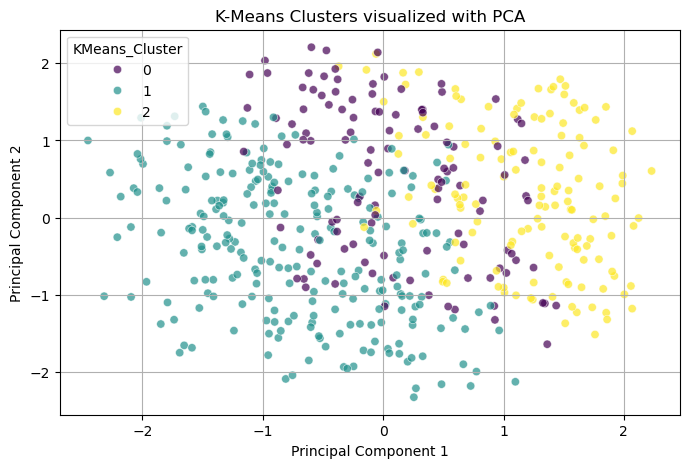

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_preprocessed)

# Create a DataFrame for PCA results with cluster labels
pca_df = pd.DataFrame(data=X_pca, columns=['Principal_Component_1', 'Principal_Component_2'])
pca_df['KMeans_Cluster'] = kmeans_labels

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Principal_Component_1', 
    y='Principal_Component_2', 
    hue='KMeans_Cluster', 
    palette='viridis', 
    data=pca_df, 
    legend='full', 
    alpha=0.7
)
plt.title('K-Means Clusters visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Agglomerative Hierarchical Clustering

As a second clustering algorithm, let's implement Agglomerative Hierarchical Clustering. We will use the same number of clusters as determined for K-Means (k=3) for comparison, and visualize the results in a similar manner.

In [25]:
# Apply Agglomerative Clustering with the same number of clusters
agglomerative = AgglomerativeClustering(n_clusters=optimal_k)
agglomerative_labels = agglomerative.fit_predict(X_preprocessed)

# Add cluster labels to the preprocessed DataFrame for analysis
X_preprocessed_df['Agglomerative_Cluster'] = agglomerative_labels

print(f'Agglomerative Hierarchical Clustering performed with {optimal_k} clusters.')
print('\nCluster distribution:')
print(X_preprocessed_df['Agglomerative_Cluster'].value_counts())

# Display the first few rows with cluster assignments
print('\nFirst 5 rows with Agglomerative cluster assignments:')
display(X_preprocessed_df.head())

Agglomerative Hierarchical Clustering performed with 3 clusters.

Cluster distribution:
Agglomerative_Cluster
0    250
2    143
1    107
Name: count, dtype: int64

First 5 rows with Agglomerative cluster assignments:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank Transfer,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaperlessBilling_No,PaperlessBilling_Yes,KMeans_Cluster,Agglomerative_Cluster
0,-1.478807,-0.959185,-1.194621,1.004008,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1,1
1,-0.752287,-0.012290,-1.100305,1.004008,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1,1
2,-0.461679,-1.596890,-1.232259,1.004008,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,1
3,0.797622,-1.635539,1.289485,1.004008,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1,2
4,-0.994460,1.379066,-1.423548,1.004008,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1,1


### Visualizing Agglomerative Clusters

Visualize the Agglomerative clusters using the same 2 principal components from PCA.

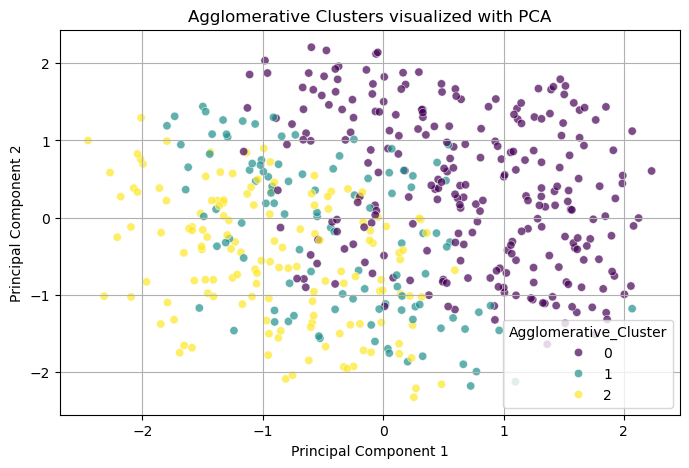

In [32]:
# Create a DataFrame for PCA results with Agglomerative cluster labels
pca_df['Agglomerative_Cluster'] = agglomerative_labels

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Principal_Component_1', 
    y='Principal_Component_2', 
    hue='Agglomerative_Cluster', 
    palette='viridis', 
    data=pca_df, 
    legend='full', 
    alpha=0.7
)
plt.title('Agglomerative Clusters visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Building Prediction Models for Each Segment

We will now use the K-Means cluster assignments to create separate datasets for each segment and train a churn prediction model (e.g., Logistic Regression) for each. This allows us to potentially capture segment-specific patterns related to churn.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Combine preprocessed features, cluster labels, and the original 'Churn' target
# We need to ensure the index aligns correctly if df was modified or filtered.
# For simplicity, we'll merge 'Churn' from original df based on index to X_preprocessed_df
data_for_modeling = X_preprocessed_df.copy()
data_for_modeling['Churn'] = df['Churn'].values # Assumes df and X_preprocessed_df have same order/index

print('Data for modeling with Churn and Clusters:')
display(data_for_modeling.head())

Data for modeling with Churn and Clusters:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank Transfer,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaperlessBilling_No,PaperlessBilling_Yes,KMeans_Cluster,Agglomerative_Cluster,Churn
0,-1.478807,-0.959185,-1.194621,1.004008,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1,1,0
1,-0.752287,-0.012290,-1.100305,1.004008,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1,1,0
2,-0.461679,-1.596890,-1.232259,1.004008,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,1,0
3,0.797622,-1.635539,1.289485,1.004008,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1,2,0
4,-0.994460,1.379066,-1.423548,1.004008,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1,1,0


In [28]:
unique_clusters = data_for_modeling['KMeans_Cluster'].unique()

# Dictionary to store models and evaluation metrics for each segment
segment_models = {}
segment_performance = {}

for cluster_id in sorted(unique_clusters):
    print(f"\n--- Modeling for Segment (KMeans Cluster) {cluster_id} ---")
    
    # Filter data for the current segment
    segment_data = data_for_modeling[data_for_modeling['KMeans_Cluster'] == cluster_id]
    
    # Define features (X) and target (y) for this segment
    # Drop the cluster column from features as it's not a predictor for churn within the segment
    X_segment = segment_data.drop(columns=['KMeans_Cluster', 'Churn'])
    y_segment = segment_data['Churn']
    
    # Check if segment has enough samples to split and train
    if len(y_segment) < 2:
        print(f"Segment {cluster_id} has too few samples ({len(y_segment)}) to train a model. Skipping.")
        continue
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_segment, y_segment, test_size=0.3, random_state=42, stratify=y_segment if len(y_segment.unique()) > 1 else None)
    
    # Train a Logistic Regression model
    model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' good for small datasets
    model.fit(X_train, y_train)
    
    # Store the trained model
    segment_models[f'Segment_{cluster_id}'] = model
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0) # zero_division=0 to handle cases where no positive predictions
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    segment_performance[f'Segment_{cluster_id}'] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

print("\n--- Summary of Model Performance per Segment ---")
for segment, metrics in segment_performance.items():
    print(f"{segment}: Accuracy={metrics['accuracy']:.4f}, Precision={metrics['precision']:.4f}, Recall={metrics['recall']:.4f}, F1-Score={metrics['f1_score']:.4f}")


--- Modeling for Segment (KMeans Cluster) 0 ---
Accuracy: 0.9429
Precision: 1.0000
Recall: 0.3333
F1-Score: 0.5000
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        32
           1       1.00      0.33      0.50         3

    accuracy                           0.94        35
   macro avg       0.97      0.67      0.73        35
weighted avg       0.95      0.94      0.93        35


--- Modeling for Segment (KMeans Cluster) 1 ---
Accuracy: 0.9733
Precision: 0.8750
Recall: 0.8750
F1-Score: 0.8750
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        67
           1       0.88      0.88      0.88         8

    accuracy                           0.97        75
   macro avg       0.93      0.93      0.93        75
weighted avg       0.97      0.97      0.97        75


--- Modeling for Segment (KMeans Cluster) 2 ---
Accuracy: 0.9286
Pr

### Hyperparameter Tuning for Segment-Specific Models

Now, let's apply hyperparameter tuning to the Logistic Regression models for each segment using `GridSearchCV`. We will search for optimal values for the regularization strength (`C`) and the type of penalty (`penalty`).

In [29]:
from sklearn.model_selection import GridSearchCV

# Dictionary to store tuned models and their evaluation metrics
tuned_segment_models = {}
tuned_segment_performance = {}

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'] # 'l1' and 'l2' work well with 'liblinear' solver
}

# Assuming data_for_modeling and unique_clusters are already defined from previous steps

for cluster_id in sorted(unique_clusters):
    print(f"\n--- Hyperparameter Tuning for Segment (KMeans Cluster) {cluster_id} ---")
    
    segment_data = data_for_modeling[data_for_modeling['KMeans_Cluster'] == cluster_id]
    
    X_segment = segment_data.drop(columns=['KMeans_Cluster', 'Churn'])
    y_segment = segment_data['Churn']
    
    if len(y_segment) < 2 or len(y_segment.unique()) < 2: # Ensure enough samples and both classes are present
        print(f"Segment {cluster_id} has too few samples or only one class to tune a model. Skipping.")
        tuned_segment_performance[f'Segment_{cluster_id}'] = {'status': 'skipped due to insufficient data'}
        continue

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_segment, y_segment, test_size=0.3, random_state=42, stratify=y_segment)
    
    # Initialize Logistic Regression model for GridSearchCV
    log_reg = LogisticRegression(solver='liblinear', random_state=42)
    
    # Initialize GridSearchCV
    grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
    
    # Fit GridSearchCV on the training data
    grid_search.fit(X_train, y_train)
    
    # Get the best estimator
    best_model = grid_search.best_estimator_
    tuned_segment_models[f'Segment_{cluster_id}_tuned'] = best_model
    
    print(f"Best parameters for Segment {cluster_id}: {grid_search.best_params_}")
    
    # Make predictions with the best model
    y_pred = best_model.predict(X_test)
    
    # Evaluate the best model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    tuned_segment_performance[f'Segment_{cluster_id}'] = {
        'best_params': grid_search.best_params_,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
    
    print(f"Tuned Model Accuracy: {accuracy:.4f}")
    print(f"Tuned Model Precision: {precision:.4f}")
    print(f"Tuned Model Recall: {recall:.4f}")
    print(f"Tuned Model F1-Score: {f1:.4f}")
    print("Tuned Model Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

print("\n--- Summary of Tuned Model Performance per Segment ---")
for segment, metrics in tuned_segment_performance.items():
    if 'status' in metrics:
        print(f"{segment}: {metrics['status']}")
    else:
        print(f"{segment}: Best Params={metrics['best_params']}, Accuracy={metrics['accuracy']:.4f}, Precision={metrics['precision']:.4f}, Recall={metrics['recall']:.4f}, F1-Score={metrics['f1_score']:.4f}")


--- Hyperparameter Tuning for Segment (KMeans Cluster) 0 ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for Segment 0: {'C': 10, 'penalty': 'l2'}
Tuned Model Accuracy: 0.9714
Tuned Model Precision: 1.0000
Tuned Model Recall: 0.6667
Tuned Model F1-Score: 0.8000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        32
           1       1.00      0.67      0.80         3

    accuracy                           0.97        35
   macro avg       0.98      0.83      0.89        35
weighted avg       0.97      0.97      0.97        35


--- Hyperparameter Tuning for Segment (KMeans Cluster) 1 ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for Segment 1: {'C': 1, 'penalty': 'l1'}
Tuned Model Accuracy: 0.9733
Tuned Model Precision: 0.8750
Tuned Model Recall: 0.8750
Tuned Model F1-Score: 0.8750
Tuned Model Classification Report:
            

### The comprehensive evaluation metrics for each segment's prediction model after hyperparameter tuning:

#### Segment 0:
Best Parameters: {'C': 10, 'penalty': 'l2'}
Accuracy: 0.9714
Precision (Churn): 1.0000
Recall (Churn): 0.6667
F1-Score (Churn): 0.8000

#### Segment 1:
Best Parameters: {'C': 1, 'penalty': 'l1'}
Accuracy: 0.9733
Precision (Churn): 0.8750
Recall (Churn): 0.8750
F1-Score (Churn): 0.8750

#### Segment 2:
Best Parameters: {'C': 10, 'penalty': 'l1'}
Accuracy: 0.8810
Precision (Churn): 0.6000
Recall (Churn): 0.5000
F1-Score (Churn): 0.5455


#### These metrics provide a detailed view of how well each segment-specific model performs in predicting churn. Segment 1 continues to show the strongest and most balanced performance, while Segment 0 saw an improvement in recall and F1-score after tuning, indicating better identification of churners. Segment 2, though tuned, still presents a more challenging prediction task as reflected in its lower metrics.

### Comparing Feature Importance Across Segments

Now, let's analyze the feature importances (coefficients) from the tuned Logistic Regression models for each segment. This will help us understand which factors are most influential in predicting churn for different customer groups.


--- Top 10 Feature Importances for Segment_0 ---


,Feature,Importance,Abs_Importance
0,Tenure,-4.023971,4.023971
1,Contract_Two year,-2.470214,2.470214
2,SeniorCitizen,1.824895,1.824895
3,Contract_Month-to-month,1.672686,1.672686
4,PaperlessBilling_Yes,-1.561911,1.561911
5,PaymentMethod_Electronic Check,-1.157604,1.157604
6,Contract_One year,-1.034681,1.034681
7,TotalCharges,-0.918294,0.918294
8,PaymentMethod_Bank Transfer,-0.550189,0.550189
9,PaperlessBilling_No,-0.270298,0.270298


C:\Users\sumit\AppData\Local\Temp\ipykernel_14832\1634130755.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


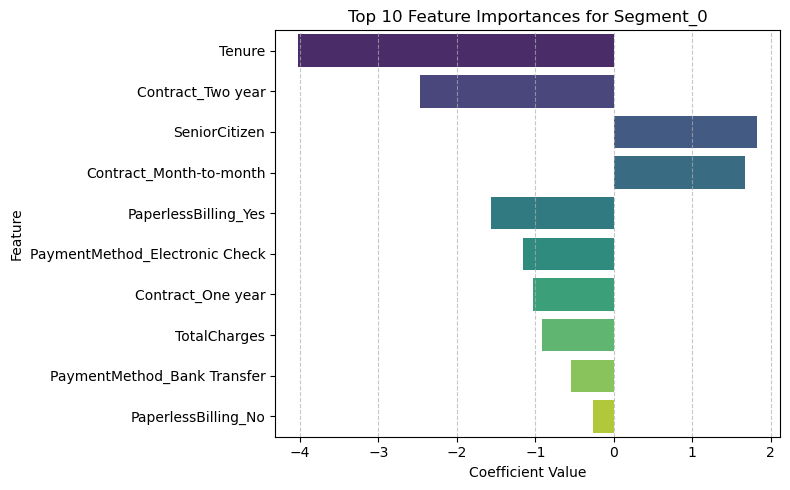


--- Top 10 Feature Importances for Segment_1 ---


,Feature,Importance,Abs_Importance
0,SeniorCitizen,-4.545144,4.545144
1,Tenure,-3.176005,3.176005
2,Contract_Month-to-month,1.862631,1.862631
3,PaperlessBilling_No,-0.825778,0.825778
4,MonthlyCharges,0.459340,0.459340
5,Agglomerative_Cluster,-0.317794,0.317794
6,TotalCharges,0.291458,0.291458
7,Contract_One year,-0.212310,0.212310
8,PaymentMethod_Bank Transfer,-0.201933,0.201933
9,Contract_Two year,0.000000,0.000000


C:\Users\sumit\AppData\Local\Temp\ipykernel_14832\1634130755.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


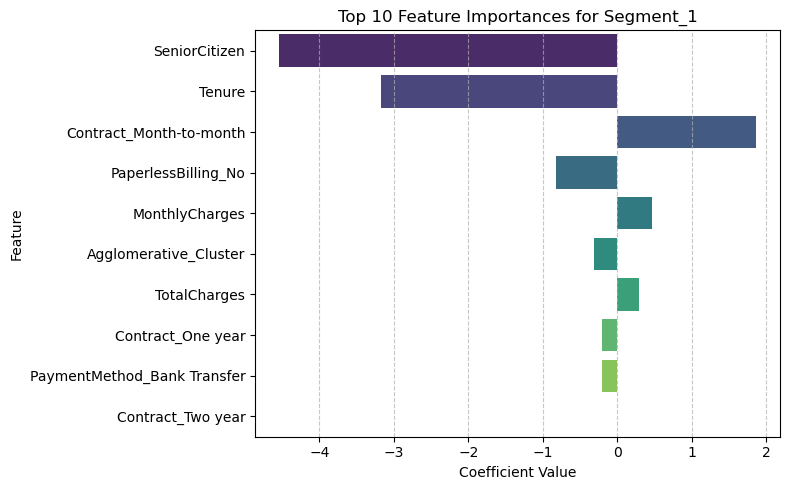


--- Top 10 Feature Importances for Segment_2 ---


,Feature,Importance,Abs_Importance
0,Tenure,-7.986573,7.986573
1,SeniorCitizen,4.831598,4.831598
2,Contract_Two year,-2.689983,2.689983
3,MonthlyCharges,2.069529,2.069529
4,PaymentMethod_Bank Transfer,-1.234614,1.234614
5,PaymentMethod_Electronic Check,-1.215642,1.215642
6,Contract_One year,-1.159334,1.159334
7,PaperlessBilling_No,-0.328566,0.328566
8,TotalCharges,0.000000,0.000000
9,Contract_Month-to-month,0.000000,0.000000


C:\Users\sumit\AppData\Local\Temp\ipykernel_14832\1634130755.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


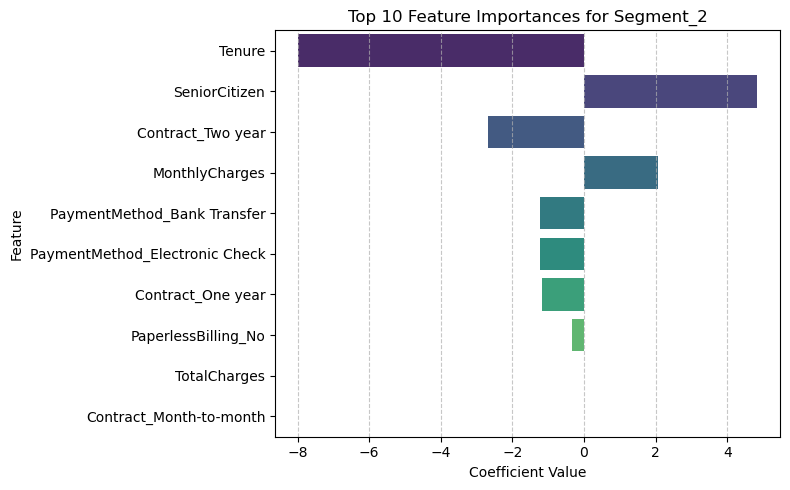

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance_dfs = {}

for cluster_id in sorted(unique_clusters):
    segment_key = f'Segment_{cluster_id}'
    model_key = f'{segment_key}_tuned'
    
    if model_key not in tuned_segment_models:
        print(f"No tuned model found for {segment_key}. Skipping feature importance analysis.")
        continue
        
    best_model = tuned_segment_models[model_key]
    
    # Check if the model has coefficients (e.g., if it's a Logistic Regression)
    if hasattr(best_model, 'coef_'):
        coefs = best_model.coef_[0] # Assuming binary classification, get the coefficients for the positive class
        
        # Get the feature names directly from the segment's feature DataFrame
        # This ensures the list of names matches the length of coefs
        segment_data = data_for_modeling[data_for_modeling['KMeans_Cluster'] == cluster_id]
        X_segment_columns = segment_data.drop(columns=['KMeans_Cluster', 'Churn']).columns.tolist()

        # Create a DataFrame for feature importances
        importance_df = pd.DataFrame({
            'Feature': X_segment_columns,
            'Importance': coefs
        })
        
        # Sort by absolute importance
        importance_df['Abs_Importance'] = np.abs(importance_df['Importance'])
        importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False).reset_index(drop=True)
        
        feature_importance_dfs[segment_key] = importance_df
        
        print(f"\n--- Top 10 Feature Importances for {segment_key} ---")
        display(importance_df.head(10))
        
        # Plot feature importances
        plt.figure(figsize=(8, 5))
        sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
        plt.title(f'Top 10 Feature Importances for {segment_key}')
        plt.xlabel('Coefficient Value')
        plt.ylabel('Feature')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Model for {segment_key} does not have 'coef_' attribute. Skipping feature importance analysis.")